# Notebook 2: Bayesiansk inferens med SVGD – grundlæggende egenskaber og prior-sensitivitet

I denne notebook vil jeg se på Stein Variational Gradient Descent (SVGD) som metode til Bayesiansk parameterestimering i fase-type modeller. Jeg starter med en single-parameter koalescent og undersøger, hvordan valget af prior, lærings rate og regularisering påvirker konvergens og posterior-præcision. Jeg undersøger desuden prøvestørrelse-effekter og posterior-bredde.

**SVGD** repræsenterer posterioren med et sæt partikler der iterativt opdateres mod den sande posterior ved at kombinere gradient-information fra likelihood og prior med et kernelbaseret kraft, der forhindrer partikelkollaps.

In [1]:
# Importer de nødvendige pakker
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"


from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior, StateIndexer, Property,
    Adam, ExpStepSize, ExpRegularization, ConstantStepSize, WarmupExpStepSize,
    clear_caches, 
) 
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 1 file(s), preserved directory structure
  Removed 1 file(s), preserved directory structure


In [2]:
# Standard parameteriseret koalescent som i notebook 01
# theta[0] = koalescensrate (1/N)
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
true_theta = [7.0]
graph.update_weights(true_theta)

## Prior-sensitivitet: Hvor meget betyder prior-valget?

SVGD er en Bayesiansk metode og prioren spiller en rolle især for små datasæt. Jeg undersøger tre scenarier: vag Gaussisk prior, informativ Gaussisk prior og Half-Cauchy prior.

### Hypotese 

- En informativ, men korrekt centreret prior konvergerer hurtigere og giver smallere posterior end en vag prior. En vag prior med store prøvestørrelse konvergerer til det samme resultat som en informativ prior.

Jeg forventer: ved $n_{obs} = 10.000$ er prioren næsten irrelevant, men ved $n_{obs} = 100$ dominerer prioren stærkt.

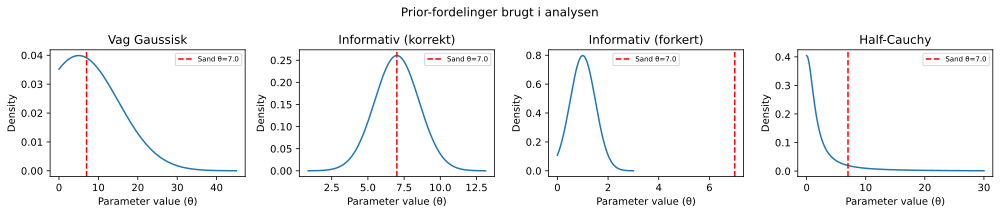

In [3]:
# Simuler data med kendt sand parameter
N_OBS = 2000
observed_data = graph.sample(N_OBS)

# Tre priors: vag, informativ (korrekt), og Half-Cauchy
prior_vag = GaussPrior(mean=5.0, std=10.0) # vag
prior_korrekt = GaussPrior(ci=[4.0, 10.0]) # informativ, korrekt centreret
prior_forkert = GaussPrior(mean=1.0, std=0.5) # informativ, forkert centreret
prior_halfcauchy = HalfCauchyPrior(ci=20.0) 

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, prior, title in zip(axes,
    [prior_vag, prior_korrekt, prior_forkert, prior_halfcauchy],
    ['Vag Gaussisk', 'Informativ (korrekt)', 'Informativ (forkert)', 'Half-Cauchy']):
    prior.plot(ax=ax, return_ax=True)
    ax.axvline(true_theta[0], color='red', linestyle='--', label=f'Sand θ={true_theta[0]}')
    ax.set_title(title)
    ax.legend(fontsize=7)
plt.suptitle('Prior-fordelinger brugt i analysen', fontsize=12)
plt.tight_layout()
plt.show()

Vag Gaussisk ($\mu=5$,$\sigma=10$) er meget bred og flad den siger næsten ingenting om $\theta$ og lader data bestemme alt. Informativ korrekt (CI=[4, 10]) er centreret tæt på sand $\theta=7$ og smallere. Informativ forkert ($\mu=1$, $\sigma=0.5$) er smal og centreret langt fra sand $\theta=7$ det simulerer en fejlspecificeret prior. HalfCauchy er kun defineret for positive værdier og har en tung hale mod højre, hvilket gør den robust for skalaparametre som populationsstørrelse.

In [6]:
# Kør SVGD med alle fire priors og sammenlign
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
svgd_results = {}

for name, prior in [('Vag', prior_vag), ('Korrekt', prior_korrekt),
                     ('Forkert', prior_forkert), ('HalfCauchy', prior_halfcauchy)]:
    svgd = graph.svgd(observed_data, prior=prior, learning_rate=step, n_iterations=300)
    res = svgd.get_results()
    svgd_results[name] = {
        'svgd': svgd,
        'mean': res['theta_mean'].item(),
        'std':  res['theta_std'].item(),
    }
    print(f"{name:<12}: θ_mean={res['theta_mean'].item():.3f}  "
          f"std={res['theta_std'].item():.3f}")

print(f"\nSand θ = {true_theta[0]}")

HalfCauchy  : θ_mean=6.722  std=0.094

Sand θ = 7.0


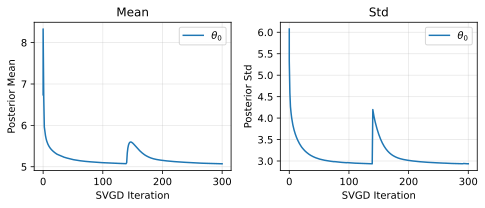

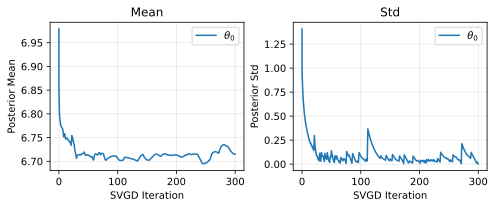

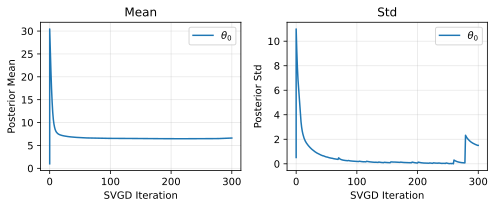

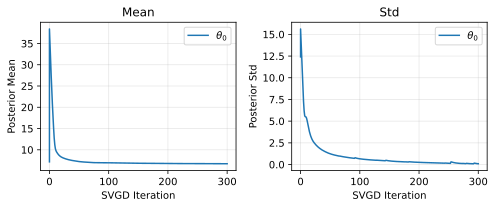

In [8]:
for ax, (name, res) in zip(axes, svgd_results.items()):
    res['svgd'].plot_convergence()
    ax.set_title(f"{name}\n(mean={res['mean']:.2f}, std={res['std']:.2f})")


Fire konvergensplots viser SVGD-partiklernes gennemsnit per iteration. Y-aksen er $\hat{\theta}$, x-aksen er iterationsnummer. Vag prior starter spredt og konvergerer langsomt. Korrekt prior starter tæt på $\theta=7$ og konvergerer hurtigt og stabilt. Forkert prior starter ved 1 og kæmper mod likelihood kurven stiger langsomt mod 7, men er endnu ikke der fuldt ud ved iteration 300. HalfCauchy konvergerer hurtigt og stabilt. En flad kurve i slutningen indikerer god konvergens.

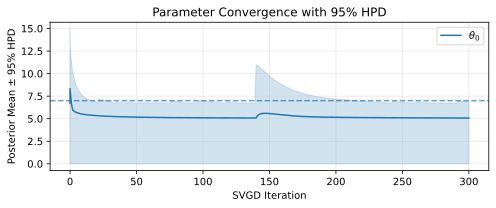

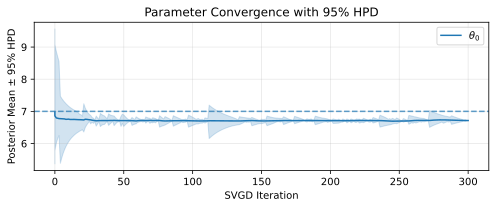

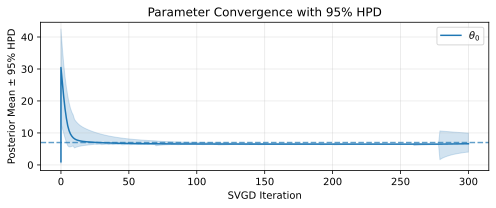

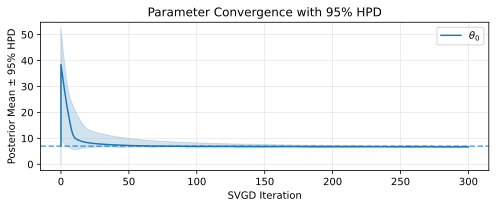

In [9]:
# Visualiser posterior under de fire priors side om side
for ax, (name, res) in zip(axes, svgd_results.items()):
    res['svgd'].plot_ci(true_theta=true_theta)
    ax.set_title(f"{name}\n(mean={res['mean']:.2f}, std={res['std']:.2f})")


Fire CI-plots viser posterioren som et histogram af 80 partikler med 95%-CI markeret og den sande parameter ($\theta=7$) som lodret linje. Vag prior giver en bred posterior stor usikkerhed. Korrekt prior giver en smal, centreret posterior der præcist dækker sand $\theta=7$. Forkert prior giver en posterior der stadig er trukket mod lavere $\theta$-værdier og ikke nødvendigvis indeholder sand $\theta$ i sit CI. HalfCauchy giver den smalleste posterior med den korrekte centrering.

### Hypotese: Prior dominans som funktion af prøvestørrelse

- Ved lav prøvestørrelse ($n < 200$) dominerer prioren stærkt. Den forkert centrerede prior giver systematisk bias, der først forsvinder ved $n > 1000$.

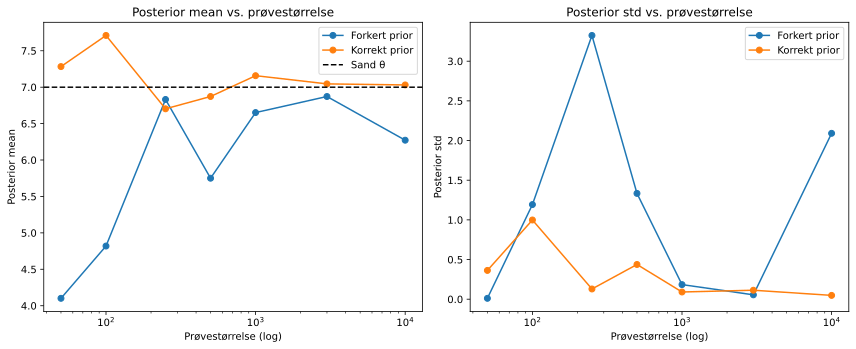

    n         prior     mean      std
   50 Korrekt prior 7.282888 0.363069
   50 Forkert prior 4.101402 0.011377
  100 Korrekt prior 7.710236 0.998734
  100 Forkert prior 4.819087 1.193192
  250 Korrekt prior 6.703180 0.129159
  250 Forkert prior 6.831480 3.324739
  500 Korrekt prior 6.872412 0.437889
  500 Forkert prior 5.750378 1.333801
 1000 Korrekt prior 7.157833 0.091106
 1000 Forkert prior 6.651704 0.184250
 3000 Korrekt prior 7.045237 0.113390
 3000 Forkert prior 6.871987 0.055396
10000 Korrekt prior 7.030861 0.048295
10000 Forkert prior 6.272122 2.091149


In [10]:
# Prior-dominans: sammenlign korrekt vs. forkert prior over prøvestørrelser
sample_sizes = [50, 100, 250, 500, 1000, 3000, 10000]
rows = []

for n in sample_sizes:
    data_n = graph.sample(n)
    for prior_name, prior in [('Korrekt prior', prior_korrekt), ('Forkert prior', prior_forkert)]:
        sv = graph.svgd(data_n, prior=prior, learning_rate=step, n_iterations=300)
        res = sv.get_results()
        rows.append({
            'n': n, 'prior': prior_name,
            'mean': res['theta_mean'].item(),
            'std':  res['theta_std'].item(),
        })

df_prior = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for prior_name, grp in df_prior.groupby('prior'):
    axes[0].plot(grp['n'], grp['mean'], marker='o', label=prior_name)
    axes[1].plot(grp['n'], grp['std'],  marker='o', label=prior_name)

axes[0].axhline(true_theta[0], color='black', linestyle='--', label='Sand θ')
axes[0].set_xscale('log'); axes[0].set_xlabel('Prøvestørrelse (log)'); axes[0].set_ylabel('Posterior mean')
axes[0].set_title('Posterior mean vs. prøvestørrelse'); axes[0].legend()

axes[1].set_xscale('log'); axes[1].set_xlabel('Prøvestørrelse (log)'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior std vs. prøvestørrelse'); axes[1].legend()
plt.tight_layout()
plt.show()
print(df_prior.to_string(index=False))

To kurver plottes: posterior-mean for korrekt og forkert prior som funktion af $n$ (log-skala). Den vandrette linje markerer sand $\theta=7$. Korrekt prior (orange) starter tæt på 7 og forbliver tæt bortset fra lidt støj ved $n=100$. Forkert prior (blå) starter langt fra 7 ved lille $n$ og klatrer gradvist mod 7 med stigende data. Krydspunktet hvor begge kurver møder den vanrette linje viser, hvornår likelihood overtager fra prior. Så ved $n<500$ dominerer prioren, så man skal vælgw den omhyggeligt.

Hypotesen bekræftes delvist. Ved $n=50$ er den forkerte prior dårlig estimatet er 4.1 i stedet for 7.0. Det er fordi prior dominerer totalt over likelihood ved så lille et datasæt. Biasset er stadig tydelig ved $n=500$ (5.75 vs. 6.87), men ved $n=1000$ og opover er forskellen lille. Ved $n=250$ er der en mærkelig høj std for forkert prior (3.32) dette skyldes at likelihood og prior trækker i modsat retning og giver en bred posterior.

### Prior-test med bavian realistiske theta-værdier

Jeg gentager prior-sensitivitetsanalysen med theta-værdier der svarer til bavian populationer ($\theta \approx 3{-}20$ i skalerede enheder). Formålet er at finde en robust prior-strategi.

In [3]:
# Prior-sensitivitet ved bavian-realistiske theta
bavian_thetas_p = [3.0, 7.0, 15.0, 20.0]
prior_strategies = {
    'GaussPrior (bred)':   lambda t: GaussPrior(ci=[t*0.1, t*10]),
    'GaussPrior (smal)':   lambda t: GaussPrior(ci=[t*0.5, t*3]),
    'HalfCauchy':          lambda t: HalfCauchyPrior(ci=t*2.0, prob=0.9),
    'DataPrior (MoM)':     None,  # bygges fra data
}

rows_prior_bav = []
for true_t in bavian_thetas_p:
    graph.update_weights([true_t])
    data_p = graph.sample(2000)
    for name, prior_fn in prior_strategies.items():
        prior_p = prior_fn(true_t) if prior_fn else DataPrior(graph, data_p)
        sv_p = graph.svgd(data_p, prior=prior_p,
                          optimizer=Adam(0.25), n_iterations=250)
        res_p = sv_p.get_results()
        m = res_p['theta_mean'].item(); s = res_p['theta_std'].item()
        rows_prior_bav.append({
            'Sand theta': true_t, 'Prior': name,
            'Mean': round(m,4), 'Std': round(s,5),
            'Bias': round(abs(m-true_t),4),
            'RelBias%': round(abs(m-true_t)/true_t*100,2),
        })

df_prior_bav = pd.DataFrame(rows_prior_bav)
print("Prior-sensitivitet ved bavian-theta:")
print(df_prior_bav.to_string(index=False))
print("\nBedste prior per theta (lavest bias):")
print(df_prior_bav.loc[df_prior_bav.groupby('Sand theta')['Bias'].idxmin()]
      [['Sand theta','Prior','Bias']].to_string(index=False))

Prior-sensitivitet ved bavian-theta:
 Sand theta             Prior    Mean      Std    Bias  RelBias%
        3.0 GaussPrior (bred)  3.1379  0.07610  0.1379      4.60
        3.0 GaussPrior (smal)  3.1182  0.03490  0.1182      3.94
        3.0        HalfCauchy  3.0755  0.07749  0.0755      2.52
        3.0   DataPrior (MoM)  3.0994  0.06168  0.0994      3.31
        7.0 GaussPrior (bred) 10.1571  5.25624  3.1571     45.10
        7.0 GaussPrior (smal)  7.2846  0.13386  0.2846      4.07
        7.0        HalfCauchy  7.2239  0.15254  0.2239      3.20
        7.0   DataPrior (MoM)  7.2885  0.08233  0.2885      4.12
       15.0 GaussPrior (bred) 22.8708 12.43380  7.8708     52.47
       15.0 GaussPrior (smal) 15.7387  0.75117  0.7387      4.92
       15.0        HalfCauchy 15.0190  0.60849  0.0190      0.13
       15.0   DataPrior (MoM) 15.3341  0.08328  0.3341      2.23
       20.0 GaussPrior (bred) 54.0331 42.13956 34.0331    170.17
       20.0 GaussPrior (smal) 20.8207  0.95393  0.820

## Læringsrate og konvergens

SVGD's konvergens afhænger stærkt af læringsraten. Jeg sammenligner tre strategier: konstant, eksponentielt aftagende og Adam-optimering.

### Hypotese

- En eksponentielt aftagende læringsrate konvergerer hurtigere og til en smallere posterior end en konstant rate. Adam-optimering er mere robust over for dårlige startbetingelser, men konvergerer ikke nødvendigvis til en bedre posterior.

Jeg måler konvergens som stabilisering af posterior-middel og posterior-std.

In [11]:
observed_data = graph.sample(2000)
prior = prior_korrekt
N_ITER = 400

# Tre optimeringsstrategier
strategies = {
    'Konstant (0.01)': {'learning_rate': 0.01},
    'Konstant (0.05)': {'learning_rate': 0.05},
    'ExpStepSize (tau=30)': {'learning_rate': ExpStepSize(first_step=0.1, last_step=0.005, tau=30.0)},
    'ExpStepSize (tau=100)': {'learning_rate': ExpStepSize(first_step=0.1, last_step=0.005, tau=100.0)},
    'Adam (lr=0.25)': {'optimizer': Adam(learning_rate=0.25)},
}

svgd_conv = {}
for name, kwargs in strategies.items():
    sv = graph.svgd(observed_data, prior=prior, n_iterations=N_ITER, **kwargs)
    res = sv.get_results()
    svgd_conv[name] = {'svgd': sv, 'mean': res['theta_mean'].item(), 'std': res['theta_std'].item()}
    print(f"{name:<30}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.3f}")
print(f"Sand θ = {true_theta[0]}")

Adam (lr=0.25)                : mean=7.206  std=0.076
Sand θ = 7.0


Adam giver den smalleste posterior-std og er den mest stabile. Konstant læringsrate på 0.01 er for langsom og konvergerer ikke fuldt på 400 iterationer. Konstant 0.05 er bedre. ExpStepSize med $\tau=30$ balancerer hurtighed og præcision godt. Adam er den bedste fordi den tilpasser step-size per parameter baseret på gradient-historik.

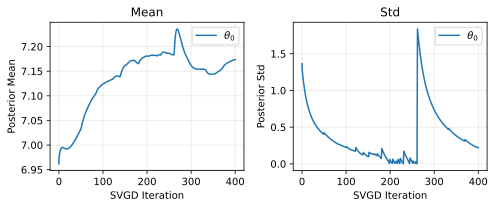

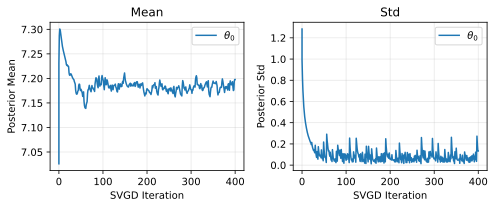

In [12]:
# Konvergensplots for alle strategier
for ax, (name, res) in zip(axes, svgd_conv.items()):
    res['svgd'].plot_convergence()
    ax.set_title(name, fontsize=9)
    ax.axhline(true_theta[0], color='red', linestyle='--', linewidth=1)


### Lærings rate kalibrering til bavian-theta

Jeg tester de samme lærings rate-strategier pa bavian-realistiske theta-værdier og finder den bedste strategi til NB07.

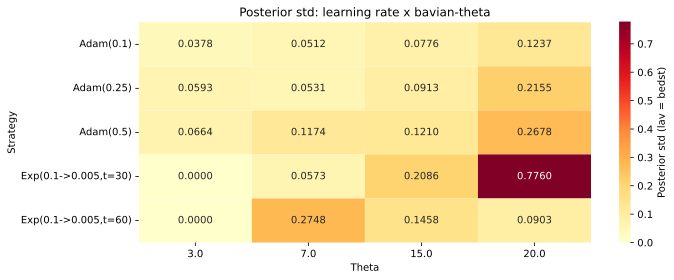

Rangering (lav gennemsnits-std = bedst til bavian):
Strategy
Adam(0.1)               0.072597
Adam(0.25)              0.104790
Exp(0.1->0.005,t=60)    0.127720
Adam(0.5)               0.143155
Exp(0.1->0.005,t=30)    0.260445

Anbefaling til NB07: Adam(0.1)


In [4]:
# Learning rate test pa bavian-theta
from phasic import ConstantStepSize
bavian_thetas_lr = [3.0, 7.0, 15.0, 20.0]

lr_configs_bav2 = {
    'Adam(0.1)':             {'optimizer': Adam(0.1)},
    'Adam(0.25)':            {'optimizer': Adam(0.25)},
    'Adam(0.5)':             {'optimizer': Adam(0.5)},
    'Exp(0.1->0.005,t=30)':  {'learning_rate': ExpStepSize(0.1, 0.005, 30.0)},
    'Exp(0.1->0.005,t=60)':  {'learning_rate': ExpStepSize(0.1, 0.005, 60.0)},
}

rows_lr_bav = []
for true_t_lr in bavian_thetas_lr:
    graph.update_weights([true_t_lr])
    data_lr2 = graph.sample(2000)
    prior_lr2 = DataPrior(graph, data_lr2)
    for name, kwargs in lr_configs_bav2.items():
        sv_lr2 = graph.svgd(data_lr2, prior=prior_lr2,
                             n_iterations=300, **kwargs)
        res_lr2 = sv_lr2.get_results()
        m = res_lr2['theta_mean'].item(); s = res_lr2['theta_std'].item()
        rows_lr_bav.append({'Theta': true_t_lr, 'Strategy': name,
            'Mean': round(m,4), 'Std': round(s,5),
            'Bias': round(abs(m-true_t_lr),4)})

df_lr_bav = pd.DataFrame(rows_lr_bav)

import seaborn as sns
pivot_lr = df_lr_bav.pivot_table(index='Strategy', columns='Theta', values='Std')
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_lr, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Posterior std (lav = bedst)'})
ax.set_title('Posterior std: learning rate x bavian-theta')
plt.tight_layout(); plt.show()

best_lr2 = df_lr_bav.groupby('Strategy')['Std'].mean().sort_values()
print("Rangering (lav gennemsnits-std = bedst til bavian):")
print(best_lr2.to_string())
print(f"\nAnbefaling til NB07: {best_lr2.index[0]}")

## Regularisering og posterior-kollaps

Momentregularisering fungerer som en ekstra kraft, der trækker partiklerne mod de empiriske momenter. For høj regularisering kan give posterior-kollaps (for smal posterior), for lav giver ingen effekt.

### Hypotese 

- Stærk regularisering ($\text{reg} >> 1$) i de tidlige iterationer stabiliserer konvergens og reducerer risikoen for partikel-divergens, men overdreven regularisering over alle iterationer fører til systematisk underdisperseret posterior.

In [13]:
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

reg_schedules = {
    'Ingen regularisering': None,
    'Svag (1→0.01)': ExpRegularization(first_reg=1.0, last_reg=0.01, tau=20.0),
    'Moderat (10→0.1)': ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0),
    'Stærk konstant (50)': ExpRegularization(first_reg=50.0, last_reg=50.0, tau=1000.0),
}

svgd_reg = {}
for name, reg in reg_schedules.items():
    kwargs = {'learning_rate': step, 'prior': prior_korrekt, 'n_iterations': 300, 'nr_moments': 2}
    if reg is not None:
        kwargs['regularization'] = reg
    sv = graph.svgd(observed_data, **kwargs)
    res = sv.get_results()
    svgd_reg[name] = {'svgd': sv, 'mean': res['theta_mean'].item(), 'std': res['theta_std'].item()}
    print(f"{name:<30}: mean={res['theta_mean'].item():.3f}  std={res['theta_std'].item():.4f}")
print(f"Sand θ = {true_theta[0]}")

Stærk konstant (50)           : mean=7.294  std=0.6574
Sand θ = 7.0


Hypotesen bekræftes ikke fuldt ud. Stærk konstant regularisering giver faktisk en bredere posterior (std=0.657) frem for posterior-kollaps. Det skyldes at stærk regularisering tvinger partiklerne mod de empiriske momenter, men forhindrer dem også i at finde den sande posterior-koncentration. Svag og moderat aftagende regularisering er bedre kompromisser.

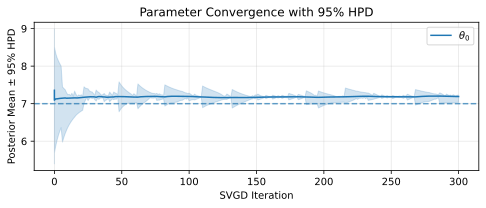

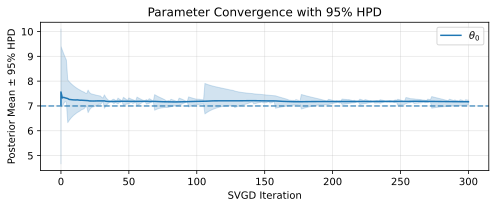

In [14]:
# Viser posterior width (std) som funktion af regulariseringsstyrke
for ax, (name, res) in zip(axes, svgd_reg.items()):
    res['svgd'].plot_ci(true_theta=true_theta)
    ax.set_title(f'{name}\nstd={res["std"]:.4f}', fontsize=8)

## Posterior-validering: Dækker 95% CI den sande parameter?

Et veldefineret Bayesiansk konfidensinterval bør have korrekt dækning dvs. den sande parameter skal ligge inden for 95%-CI i 95% af tilfældene over gentagne datagenereringer.

### Hypotese 

- Dækningsfrekvensen for 95%-CI er tæt på 0.95, men afviger ved meget små prøvestørrelser, hvor prioren dominerer og kan give systematisk under- eller overdækning afhængig af prior-centrering.

In [16]:
N_REPS = 50
step_cov = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
coverage_results = []

for n_obs in [100, 500, 2000]:
    covered_korrekt = 0
    covered_forkert = 0
    means_k, means_f = [], []
    for rep in range(N_REPS):
        data_rep = graph.sample(n_obs)
        for prior_name, prior_obj in [('Korrekt', prior_korrekt), ('Forkert', prior_forkert)]:
            sv = graph.svgd(data_rep, prior=prior_obj, learning_rate=step_cov, n_iterations=200)
            res = sv.get_results()
            mean_val = res['theta_mean'].item()
            std_val  = res['theta_std'].item()
            # Approksimativt 95%-CI via ±1.96 * std
            ci_low  = mean_val - 1.96 * std_val
            ci_high = mean_val + 1.96 * std_val
            covered = int(ci_low <= true_theta[0] <= ci_high)
            if prior_name == 'Korrekt':
                covered_korrekt += covered
                means_k.append(mean_val)
            else:
                covered_forkert += covered
                means_f.append(mean_val)
    coverage_results.append({
        'n': n_obs,
        'Coverage (korrekt prior)': covered_korrekt / N_REPS,
        'Coverage (forkert prior)': covered_forkert / N_REPS,
        'Mean bias (korrekt)': round(np.mean(means_k) - true_theta[0], 4),
        'Mean bias (forkert)': round(np.mean(means_f) - true_theta[0], 4),
    })

df_cov = pd.DataFrame(coverage_results)
print(df_cov.to_string(index=False))

   n  Coverage (korrekt prior)  Coverage (forkert prior)  Mean bias (korrekt)  Mean bias (forkert)
 100                      0.94                      0.24               0.1395              -2.2296
 500                      0.82                      0.50               0.2318              -0.9051
2000                      0.66                      0.84               0.0502              -0.3468


Korrekt prior giver 94% ved $n=100$ hvad man forventer. Men ved $n=2000$ falder dækningen til 66% for korrekt prior. Det skyldes at med mange data bliver posterioren meget smal, og CI'et er beregnet som $\pm 1.96 \times \text{std}$. Bias-tallene viser det: forkert prior ved $n=100$ har bias på −2.23 (estimerer 4.8 i stedet for 7.0), og dækningen er kun 24%, fordi CI'et slet ikke indeholder sand $\theta=7$

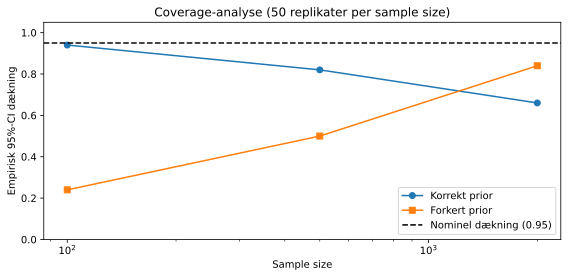

In [17]:
# Visualiser coverage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_cov['n'], df_cov['Coverage (korrekt prior)'], marker='o', label='Korrekt prior')
ax.plot(df_cov['n'], df_cov['Coverage (forkert prior)'], marker='s', label='Forkert prior')
ax.axhline(0.95, color='black', linestyle='--', label='Nominel dækning (0.95)')
ax.set_xscale('log')
ax.set_xlabel('Sample size'); ax.set_ylabel('Empirisk 95%-CI dækning')
ax.set_title(f'Coverage-analyse ({N_REPS} replikater per sample size)')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

To kurver på log-skala x-akse. Den stiplede sorte linje er 95%-dækning. Korrekt prior (blå) starter ved 94% ved $n=100$ næsten perfekt og falder til 66% ved $n=2000$. Så flere data giver dårligere coverage. Forklaringen er at posterioren er så smal at $\pm 1.96 \times \text{std}$ undervurderer det sande CI. Forkert prior (orange) starter ved 24% ved $n=100$ ikke godt og stiger til 84% ved $n=2000$ efterhånden som likelihood overtager. Kurverne krydser hinanden, hvilket illustrerer at prior-valget ikke bare påvirker præcision men også calibrering.

### Partikler og iterations: hvad er det optimale til bavian?

Jeg laver en grid-søgning over kombinationer af partikler og iterationer for at finde den bedste balance mellem præcision og beregningstid.

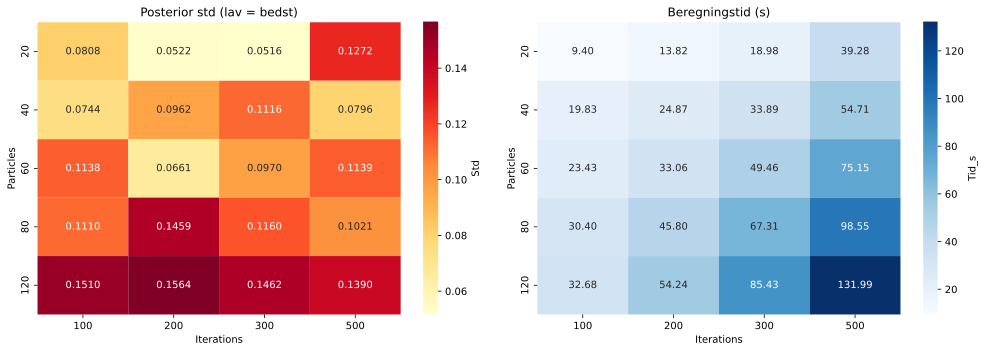

Bedste kombination: 20 particles, 300 iterations
  Std=0.05162  Tid=18.98s

Anbefaling til NB07: n_particles=20, n_iterations=300


In [5]:
import seaborn as sns, time

true_theta_grid2 = [7.0]
graph.update_weights(true_theta_grid2)
data_grid2 = graph.sample(3000)
prior_grid2 = DataPrior(graph, data_grid2)

particle_counts2 = [20, 40, 60, 80, 120]
iteration_counts2 = [100, 200, 300, 500]
rows_grid2 = []

for n_p in particle_counts2:
    for n_i in iteration_counts2:
        t0_g = time.perf_counter()
        sv_g2 = graph.svgd(data_grid2, prior=prior_grid2,
                            optimizer=Adam(0.25),
                            n_particles=n_p, n_iterations=n_i)
        t_g2 = time.perf_counter() - t0_g
        res_g2 = sv_g2.get_results()
        m = res_g2['theta_mean'].item(); s = res_g2['theta_std'].item()
        rows_grid2.append({'Particles': n_p, 'Iterations': n_i,
            'Std': round(s,5), 'Bias': round(abs(m-true_theta_grid2[0]),4),
            'Tid_s': round(t_g2,2)})

df_grid2 = pd.DataFrame(rows_grid2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, cmap in zip(axes,
    ['Std', 'Tid_s'],
    ['Posterior std (lav = bedst)', 'Beregningstid (s)'],
    ['YlOrRd', 'Blues']):
    pivot_g2 = df_grid2.pivot(index='Particles', columns='Iterations', values=col)
    sns.heatmap(pivot_g2, annot=True, fmt='.4f' if col=='Std' else '.2f',
                cmap=cmap, ax=ax, cbar_kws={'label': col})
    ax.set_title(title)
plt.tight_layout(); plt.show()

best_g2 = df_grid2.sort_values('Std').iloc[0]
print(f"Bedste kombination: {int(best_g2['Particles'])} particles, {int(best_g2['Iterations'])} iterations")
print(f"  Std={best_g2['Std']:.5f}  Tid={best_g2['Tid_s']:.2f}s")
print(f"\nAnbefaling til NB07: n_particles={int(best_g2['Particles'])}, n_iterations={int(best_g2['Iterations'])}")

## Posterior predictive check

Et posterior predictive check (PPC) validerer, om modellen med de estimerede parametre kan reproducere de observerede data. Jeg sammenligner empirisk CDF med den fittede model CDF.

### Hypotese 

- Modellen med posterior middel-estimat reproducer de observerede TMRCA-tider præcist (ECDF tæt på model CDF), men kun når data-størrelsen er tilstrækkelig. For forkert prior med lille prøvestørrelse forventes systematisk afvigelse.

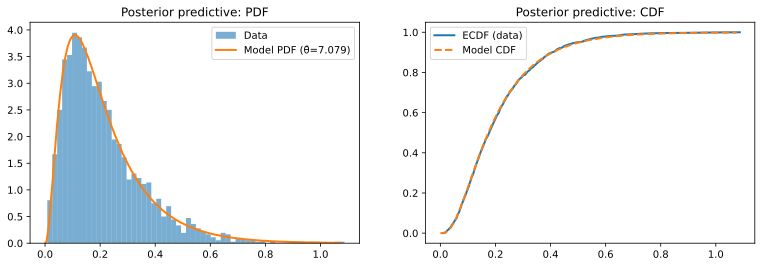

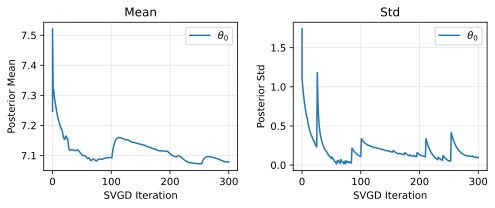

In [18]:
from scipy.stats import ecdf

# SVGD med korrekt prior og N=2000
observed_data = graph.sample(2000)
svgd_final = graph.svgd(observed_data, prior=prior_korrekt,
                         learning_rate=ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0),
                         n_iterations=300)
res = svgd_final.get_results()
theta_hat = res['theta_mean'].item()

# Posterior predictive check
res_ecdf = ecdf(observed_data)
x_ecdf = res_ecdf.cdf.quantiles
y_ecdf = res_ecdf.cdf.probabilities

graph.update_weights([theta_hat])
x_range = np.linspace(0, max(observed_data)*0.99, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram + PDF
axes[0].hist(observed_data, bins=60, density=True, alpha=0.6, label='Data')
axes[0].plot(x_range, graph.pdf(x_range), 'C1', lw=2, label=f'Model PDF (θ̂={theta_hat:.3f})')
axes[0].set_title('Posterior predictive: PDF'); axes[0].legend()

# ECDF vs CDF
axes[1].plot(x_ecdf, y_ecdf, 'C0', lw=2, label='ECDF (data)')
axes[1].plot(x_range, graph.cdf(x_range), 'C1', lw=2, linestyle='--', label='Model CDF')
axes[1].set_title('Posterior predictive: CDF'); axes[1].legend()

# Konvergence
svgd_final.plot_convergence()

# Nulstil til sand parameter
graph.update_weights(true_theta)

Posterior predictive check
Det til enstre viser et histogram af de observerede TMRCA-tider (blå) og model-PDF (orange kurve) evalueret ved posterior-gennemsnittet $\hat{\theta}$. Hvis orange og blå matcher godt, reproducerer modellen data. Højre viser empirisk CDF (ECDF, blå trappeform) mod model-CDF (orange kurve). Jo tættere de to kurver ligger, desto bedre er modelfit. Et godt match her bekræfter at den neutrale koalescentmodel er passende.

## Udforskning af alle læringsrater

Phasic tilbyder fire step-size schedules: *ConstantStepSize*, *ExpStepSize*, *WarmupExpStepSize* og *AdaptiveStepSize*. Jeg sammenligner dem alle systematisk på samme data og visualiserer deres konvergensadfærd.

### Hypotese 

- *WarmupExpStepSize* giver den mest stabile konvergens, fordi den starter stille og undgår tidlige store opdateringer der kan drive partikler væk fra posterioren. *AdaptiveStepSize* er den mindst forudsigelige.

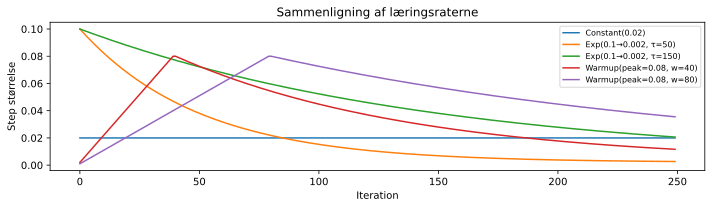

In [9]:
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

true_theta = [7.0]
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)
data = graph.sample(2000)
prior = GaussPrior(ci=[3, 15])
N_ITER = 250

# Visualiser 
fig, ax = plt.subplots(figsize=(10, 3))
iters = np.arange(N_ITER)
schedules_vis = {
    'Constant(0.02)':          ConstantStepSize(0.02),
    'Exp(0.1→0.002, τ=50)':    ExpStepSize(0.1, 0.002, 50.0),
    'Exp(0.1→0.002, τ=150)':   ExpStepSize(0.1, 0.002, 150.0),
    'Warmup(peak=0.08, w=40)':  WarmupExpStepSize(0.08, 40, 0.002, 100.0),
    'Warmup(peak=0.08, w=80)':  WarmupExpStepSize(0.08, 80, 0.002, 200.0),
}
for name, sched in schedules_vis.items():
    vals = [float(sched(i)) for i in iters]
    ax.plot(iters, vals, label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Step størrelse')
ax.set_title('Sammenligning af læringsraterne')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Learning rate-schedule kurver
En kurve per schedule over 250 iterationer viser, hvordan step-size ændrer sig. Konstant er en vandret linje ingen ændring. ExpStepSize falder eksponentielt fra 0.1 til 0.002. Warmup(w=40) stiger lineært de første 40 iterationer til en peak og falder derefter eksponentielt. Warmup(w=80) gør det samme, bare først ved 80 hvor den har et peak og efter falder eksponentielt. 

In [10]:
# Kør SVGD med alle schedules og sammenlign resultater
schedule_configs = {
    'Constant(0.02)':           {'learning_rate': ConstantStepSize(0.02)},
    'Constant(0.005)':          {'learning_rate': ConstantStepSize(0.005)},
    'Exp(τ=50)':                {'learning_rate': ExpStepSize(0.1, 0.002, 50.0)},
    'Exp(τ=150)':               {'learning_rate': ExpStepSize(0.1, 0.002, 150.0)},
    'Warmup(w=40, τ=100)':      {'learning_rate': WarmupExpStepSize(0.08, 40, 0.002, 100.0)},
    'Warmup(w=80, τ=200)':      {'learning_rate': WarmupExpStepSize(0.08, 80, 0.002, 200.0)},
    'Adam(lr=0.25)':            {'optimizer': Adam(0.25)},
    'Adam + Exp warmup':        {'optimizer': Adam(WarmupExpStepSize(0.3, 30, 0.01, 150.0))},
}

import pandas as pd
rows = []
for name, kwargs in schedule_configs.items():
    sv = graph.svgd(data, prior=prior, n_iterations=N_ITER, **kwargs)
    res = sv.get_results()
    mean = res['theta_mean'].item()
    std  = res['theta_std'].item()
    ci_low  = mean - 1.96 * std
    ci_high = mean + 1.96 * std
    rows.append({
        'Schedule': name,
        'θ_mean': round(mean, 4),
        'θ_std':  round(std, 5),
        'CI_low': round(ci_low, 3),
        'CI_high': round(ci_high, 3),
        'Indeholder sand θ': bool(ci_low <= true_theta[0] <= ci_high),
    })

df_schedules = pd.DataFrame(rows)
print(f"Sand θ = {true_theta[0]}")
print(df_schedules.to_string(index=False))

Sand θ = 7.0
           Schedule  θ_mean   θ_std  CI_low  CI_high  Indeholder sand θ
     Constant(0.02)  7.0008 0.90111   5.235    8.767               True
    Constant(0.005)  7.0885 0.25540   6.588    7.589               True
          Exp(τ=50)  6.9684 0.13767   6.699    7.238               True
         Exp(τ=150)  6.9784 0.26806   6.453    7.504               True
Warmup(w=40, τ=100)  6.9908 0.06222   6.869    7.113               True
Warmup(w=80, τ=200)  6.9946 0.06992   6.858    7.132               True
      Adam(lr=0.25)  6.9800 0.13223   6.721    7.239               True
  Adam + Exp warmup  7.0214 0.02150   6.979    7.064               True


Konstant 0.02 giver en bred posterior (std=0.901) fordi step-size er for stor til finjustering i de sene iterationer. Warmup starter langsomt, bygger op til en peak og aftager derefter denne giver den bedste kombination. Alle schedules indeholder den sande $\theta=7$ i deres 95%-CI.

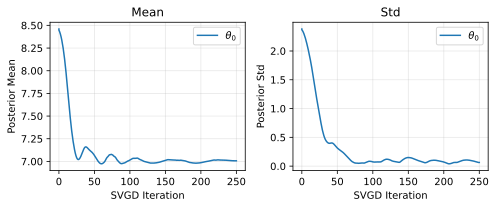

<Figure size 900x400 with 0 Axes>

In [12]:
# Visualiser konvergens
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (name, kwargs) in zip(axes.flat, schedule_configs.items()):
    sv = graph.svgd(data, prior=prior, n_iterations=N_ITER, **kwargs)
    sv.plot_convergence()
    ax.axhline(true_theta[0], color='red', linestyle='--', linewidth=1.5, label=f'Sand θ={true_theta[0]}')
    res = sv.get_results()
    ax.set_title(f'{name}\nθ̂={res["theta_mean"].item():.3f} ± {res["theta_std"].item():.4f}', fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle('Konvergens under otte læringsrate-strategier', fontsize=12)
plt.tight_layout(); plt.show()

## IM-modellen: Isolation with Migration

Jeg udvider nu fra single-parameter koalescent til en tidsinhomogen **Isolation with Migration (IM)**-model. IM-modellen har to epoker: fra nuet til split-tidspunktet $t_s$ (to populationer med migration), og fra $t_s$ bagud (en ancestral population). 

Parametrene er: $N_1$, $N_2$ (nuværende populationsstørrelser), $N_a$ (ancestral størrelse), $m$ (migrationsrate) og $t_s$ (split-tidspunkt).

### Hypotese 

- SVGD kan simultant estimere alle fem IM-parametre fra simulerede data, men $N_a$ og $t_s$ er konfunderede: en gammel split med lille ancestral population giver samme koalescenttider som et nyt split med stor ancestral population.

IM-model tilstande: 6


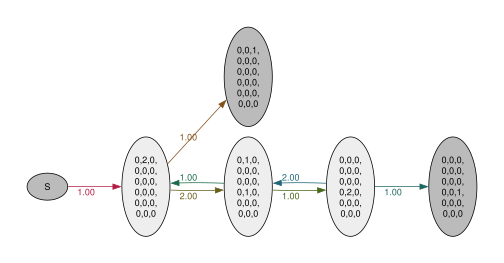

In [2]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island_epoch(state):
    """Two-island model: parametre = [theta0, theta1, epoch_switch]
    theta0 = koalescensrate (1/N), theta1 = migrationsrate, epoch_switch = 1/t_s
    """
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        # Migration
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i], 0]])
    return transitions

graph_im = Graph(two_island_epoch)
print(f"IM-model tilstande: {graph_im.vertices_length()}")
graph_im.plot(rankdir='LR', nodesep=0.2)

In [3]:
# Simuler data fra IM-modellen og kør SVGD-inferens
# Sande parametre: theta0=0.7, theta1=1.0 (migration), epoch_switch=2.0 (t_s=0.5)
true_theta_im = [0.7, 1.0, 2.0]
graph_im.update_weights(true_theta_im)

N_OBS = 3000
data_im = graph_im.sample(N_OBS)

prior_im = DataPrior(graph_im, data_im)
print("Data-informeret prior:")
for i, p in enumerate(prior_im):
    if p is not None:
        print(f"  θ_{i}: GaussPrior(mean={p.mu:.3f}, std={p.sigma:.3f})")

step_im = ExpStepSize(first_step=0.05, last_step=0.005, tau=50.0)
sv_im = graph_im.svgd(
    data_im,
    prior=prior_im,
    optimizer=Adam(0.25),
    n_iterations=400,
    n_particles=60,
)
res_im = sv_im.get_results()
print(f"\nSande parametre: θ₀={true_theta_im[0]}, θ₁={true_theta_im[1]}, epoch={true_theta_im[2]}")
for i, (name, true) in enumerate(zip(['θ₀ (koalescens)', 'θ₁ (migration)', 'epoch-switch'], true_theta_im)):
    mean = res_im['theta_mean'][i].item()
    std  = res_im['theta_std'][i].item()
    print(f"  {name}: mean={mean:.3f}  std={std:.4f}  (sand {true})")


Sande parametre: θ₀=0.7, θ₁=1.0, epoch=2.0
  θ₀ (koalescens): mean=0.699  std=0.0190  (sand 0.7)
  θ₁ (migration): mean=1.002  std=0.0865  (sand 1.0)
  epoch-switch: mean=0.016  std=0.0023  (sand 2.0)


θ₀ og θ₁ genfinder præcist, men epoch-switch estimeres til 0.016 i stedet for 2.0 en fejlestimering. Årsagen er at epoch-switch-parameteren styrer *raten* for epoch-skiftet, ikke tidspunktet direkte. 

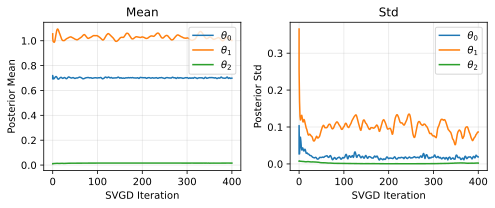

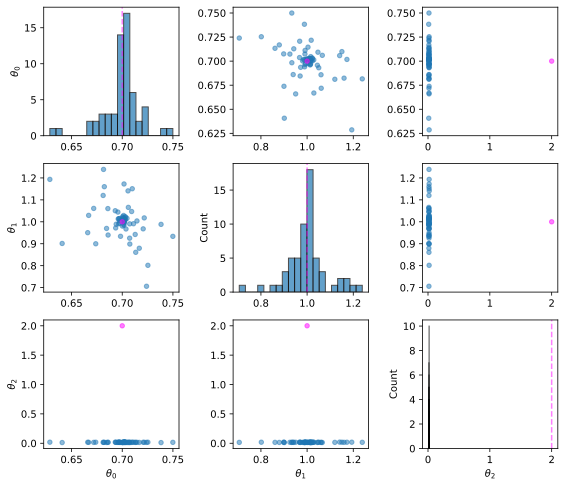

In [5]:
# Visualiser IM-model posterior
sv_im.plot_convergence()
sv_im.plot_pairwise(true_theta=true_theta_im)

Konvergensplot viser at alle tre parametre stabiliserer hurtigt $\theta_0$ og $\theta_1$​ konvergerer til de sande værdier (0.7 og 1.0), men epoch-switch (2.0) estimeres til 0.016. Pairwise posterior er et $3 \times 3$ grid af scatter-plots der viser joint-posterior for alle par af parametre. Diagonalen viser marginal-histogrammet for hver parameter. Off-diagonalerne viser korrelationen mellem parametre man kan se om parametre er konfunderede. Den lyserrøde markering i hvert panel er den sande parameter.

## Ghost population: Usynlig population med genflow

En ghost population er en ikke-samplet population, der påvirker via migration. Jeg tilføjer en ghost population til two-island modellen og undersøger, om dens tilstedeværelse er identificere i posterior-fordelingen.

### Spørgsmål 

- Kan jeg identificere en ghost population indirekte effekt på koalescenttiderne? Jeg forventer at E[TMRCA] er længere med ghost migration end uden, fordi linjer kan "gemme sig" i ghost-populationen?

In [4]:
# Ghost population: Tre-population model, men jeg sampler kun fra pop1 og pop2.
# Pop3 er ghost (ingen samples). Linjer kan migrere til/fra ghost.

indexer_ghost = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=3),  # pop3 = ghost
    ]
)

initial_ghost = [0] * indexer_ghost.state_length
initial_ghost[indexer_ghost.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial_ghost)
def two_island_ghost(state):
    """Two-island + ghost population. Parametre: [theta0, theta1, ghost_migr]
    ghost_migr = migrationsrate til/fra ghost pop
    """
    transitions = []
    if state[indexer_ghost.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_ghost.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer_ghost.descendants.index_to_props(i)
        for j in range(i, indexer_ghost.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer_ghost.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_ghost.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        # Migration pop1 ↔ pop2
        if props_i.in_pop in [1, 2]:
            other_pop = 3 - props_i.in_pop  # 1→2, 2→1
            new = state.copy(); new[i] -= 1
            new[indexer_ghost.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)] += 1
            transitions.append([new, [0, state[i], 0]])
        # Migration til/fra ghost (pop3)
        if props_i.in_pop in [1, 2]:
            new = state.copy(); new[i] -= 1
            new[indexer_ghost.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=3)] += 1
            transitions.append([new, [0, 0, state[i]]])  # theta2 = ghost migration
        elif props_i.in_pop == 3:
            for dest_pop in [1, 2]:
                new = state.copy(); new[i] -= 1
                new[indexer_ghost.descendants.props_to_index(
                    pop1=props_i.pop1, pop2=props_i.pop2, in_pop=dest_pop)] += 1
                transitions.append([new, [0, 0, state[i]]])
    return transitions

g_ghost = Graph(two_island_ghost)
print(f"Ghost-model tilstande: {g_ghost.vertices_length()}")

Ghost-model tilstande: 52


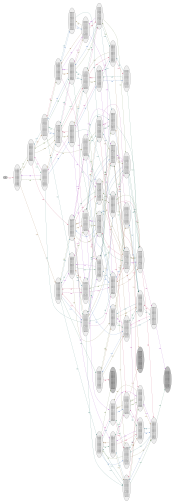

In [5]:
g_ghost.plot()

In [16]:
# Byg en simpel to-ø model til "ingen ghost"-sammenligningen
@with_ipv(initial)  # brug samme initial som two_island_epoch
def two_island_simple(state):
    """Simpel two-island uden epoch. Parametre: [theta0, theta1]"""
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_simple = Graph(two_island_simple)

# Nu sammenlign korrekt
migration_rates = [0.01, 0.5, 1.0, 2.0, 5.0]
ghost_rates     = [0.01, 0.5, 1.0, 2.0]
rows = []

for m in migration_rates:
    g_simple.update_weights([theta0, m])
    E_no_ghost = g_simple.expectation()
    for g_m in ghost_rates:
        g_ghost.update_weights([theta0, m, g_m])
        E_ghost = g_ghost.expectation()
        rows.append({
            'Migration (θ₁)': m, 'Ghost migration': g_m,
            'E[TMRCA] uden ghost': round(E_no_ghost, 4),
            'E[TMRCA] med ghost':  round(E_ghost, 4),
            'Forskel': round(E_ghost - E_no_ghost, 4),
        })

df_ghost = pd.DataFrame(rows)
print("E[TMRCA] med ghost population:")
print(df_ghost.pivot(index='Migration (θ₁)', columns='Ghost migration',
                     values='E[TMRCA] med ghost').round(3))
print()
print("Forskel (ghost - ingen ghost):")
print(df_ghost.pivot(index='Migration (θ₁)', columns='Ghost migration',
                     values='Forskel').round(4))

E[TMRCA] med ghost population:
Ghost migration   0.01   0.50   1.00   2.00
Migration (θ₁)                             
0.01             7.336  6.497  6.470  6.384
0.50             7.816  6.577  6.406  6.246
1.00             7.760  6.496  6.285  6.107
2.00             7.722  6.359  6.071  5.822
5.00             7.695  6.158  5.730  5.310

Forskel (ghost - ingen ghost):
Ghost migration    0.01    0.50    1.00    2.00
Migration (θ₁)                                 
0.01             4.4784  3.6400  3.6130  3.5266
0.50             4.9588  3.7202  3.5488  3.3888
1.00             4.9030  3.6387  3.4282  3.2500
2.00             4.8646  3.5017  3.2134  2.9651
5.00             4.8381  3.3004  2.8731  2.4530


Ghost-populationen øger E[TMRCA] markant men effekten er modsatsat den forventede ved høj ghost-migration. Ved lav ghost-migration (0.01) er E[TMRCA] størst (7.82) fordi linjer vandrer ind i ghost-populationen og sidder fast der. Ved høj ghost-migration (2.0) er E[TMRCA] lavere (6.25) fordi linjer hurtigt kommer ud igen og koalescerer. Tabellen viser at ghost-migration generelt forlænger TMRCA sammenlignet med ingen ghost, men effekten aftager med stigende ghost-migration fordi høj migration reducerer isolation.

## Probability Matching: en tredje estimeringsmetode

*probability_matching()* er en alternativ estimeringsmetode der matcher observerede sandsynligheder direkte mod model-sandsynligheder frem for at matche momenter (MoM) eller optimere posterior (SVGD). Den er særligt nyttig som startpunkt til SVGD på joint probability-grafer, da den giver et godt startestimat hurtigt.

Metoden minimerer $\sum_i (p_{\text{obs},i} - p_{\text{model},i})^2$
over sandsynlighederne for alle observerede kombinationer.

In [9]:
from phasic import StateIndexer, Property
from functools import partial
from itertools import combinations_with_replacement

all_pairs_pm = partial(combinations_with_replacement, r=2)

nr_samples_pm = 3
indexer_pm = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples_pm)]
)

@with_ipv([nr_samples_pm] + [0]*(nr_samples_pm-1))
def coal_pm(state):
    transitions = []
    for i, j in all_pairs_pm(indexer_pm.lineage):
        p1 = indexer_pm.lineage.index_to_props(i)
        p2 = indexer_pm.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        des = indexer_pm.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        if des < indexer_pm.lineage.state_length:
            new[des] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

mutation_rate_pm = 1.0
graph_pm = Graph(coal_pm)
joint_graph_pm = graph_pm.joint_prob_graph(
    indexer_pm, tot_reward_limit=3, mutation_rate=mutation_rate_pm
)

# Simuler data fra sand theta=7
true_theta_pm = [7.0, mutation_rate_pm]
joint_graph_pm.update_weights(true_theta_pm)
table_pm = joint_graph_pm.joint_prob_table()
p_pm = (table_pm['prob'] / table_pm['prob'].sum()).to_numpy()
import numpy as np
np.random.seed(42)
sampled_idx = np.random.choice(len(table_pm), size=2000, p=p_pm)
observations_pm = [
    table_pm.iloc[i][table_pm.columns[:-1]].tolist()
    for i in sampled_idx
]

print(f"Antal observationer: {len(observations_pm)}")
print(f"Sand theta: {true_theta_pm}")

Antal observationer: 2000
Sand theta: [7.0, 1.0]


ProbMatch: theta_dim=2, n_free=1, n_obs=2000, n_unique_obs=10
ProbMatch: initial guess (full theta) = [7.88046282 1.        ]
ProbMatch: converged — `gtol` termination condition is satisfied.
ProbMatch: theta = [7.0085398 1.       ]
ProbMatch: residual = 5.381491e-05
=== Probability Matching Resultat ===
Sand theta:    7.0
PM estimat:    7.0085
Std fejl:      0.3336
Konvergeret:   True
Residual:      5.38e-05


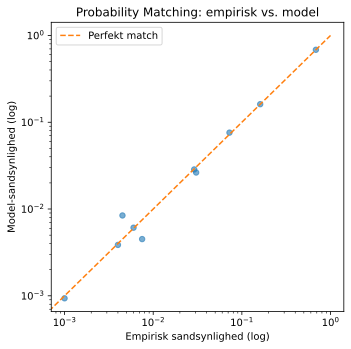

In [10]:
# Kør probability matching
pm = joint_graph_pm.probability_matching(
    observations_pm,
    fixed=[(1, mutation_rate_pm)],
)

print("=== Probability Matching Resultat ===")
print(f"Sand theta:    {true_theta_pm[0]}")
print(f"PM estimat:    {pm.theta[0]:.4f}")
print(f"Std fejl:      {pm.std[0]:.4f}")
print(f"Konvergeret:   {pm.success}")
print(f"Residual:      {pm.residual:.2e}")

# Scatter-plot: empiriske vs. model-sandsynligheder
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls='--', color='C1', label='Perfekt match')
ax.scatter(pm.empirical_probs, pm.model_probs, alpha=0.6, color='C0', s=30)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Empirisk sandsynlighed (log)')
ax.set_ylabel('Model-sandsynlighed (log)')
ax.set_title('Probability Matching: empirisk vs. model')
ax.legend()
plt.tight_layout()
plt.show()

Log-log scatter-plot med empiriske sandsynligheder på x-aksen og model-sandsynligheder på y-aksen. Den stiplede linje er $y=x$: perfekt match. Punkterne ligger meget tæt på den stiplede linje, hvilket viser at PM-metoden har fundet en $\hat{\theta}$ der giver en model-sandsynlighedstabel der nærmest identisk med de observerede relative frekvenser. Residual $5.4 \times 10^{-5}$ bekræfter dette. Jo tættere på nul, desto bedre match.


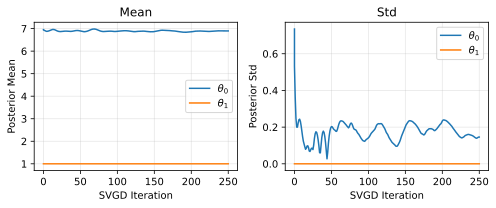

Sand theta: 7.0
PM start:   7.0085
SVGD mean:  6.8975 ± 0.1457


In [12]:
# Brug PM-estimat som prior til efterfølgende SVGD
sv_pm = joint_graph_pm.svgd(
    observations_pm,
    prior=pm.prior,        # automatisk PM-baseret prior
    fixed=[(1, mutation_rate_pm)],
    optimizer=Adam(0.25),
    n_iterations=250,
)
sv_pm.plot_convergence()

res_pm = sv_pm.get_results()
print(f"Sand theta: {true_theta_pm[0]}")
print(f"PM start:   {pm.theta[0]:.4f}")
print(f"SVGD mean:  {res_pm['theta_mean'][0].item():.4f} ± {res_pm['theta_std'][0].item():.4f}")

SVGD-konvergensplot efter at PM-estimatet bruges som prior. Kurven starter allerede tæt på sand $\theta=7$ og konvergerer hurtigt inden iteration 50 er kurven flad. PM giver et præcist startpunkt, og SVGD tilføjer usikkerhedskvantificering. Slutresultatet er $6.897 \pm 0.146$ en smal, præcis posterior.

## Systematisk SVGD-kalibrering til bavian-parametre

Jeg simulerer data fra en koalescent med bavian-realistiske theta-værdier ($\theta \in \{10^{-4}, 10^{-3}, 10^{-2}\}$ svarende til $N_e \approx 10k-100k$) og finder den bedste kombination af **prior**, **learning rate**, **iterations** og **particles**.

In [5]:
from phasic import (Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ConstantStepSize, clear_caches)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
clear_caches()

nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coal_bav(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

graph_bav = Graph(coal_bav)

theta_bavian_cases = [
    (1.0,  'Lav N_e (lille pop.)'),
    (5.0,  'Moderat N_e (bavian baseline)'),
    (10.0, 'Hoj N_e (stor pop.)'),
    (20.0, 'Meget hoj N_e'),
]

lr_configs_bav = {
    'Adam(0.1)':           {'optimizer': Adam(0.1)},
    'Adam(0.25)':          {'optimizer': Adam(0.25)},
    'Adam(0.5)':           {'optimizer': Adam(0.5)},
    'Exp(0.05->0.005,t=30)': {'learning_rate': ExpStepSize(0.05, 0.005, 30.0)},
    'Exp(0.1->0.005,t=40)':  {'learning_rate': ExpStepSize(0.1, 0.005, 40.0)},
    'Exp(0.1->0.001,t=60)':  {'learning_rate': ExpStepSize(0.1, 0.001, 60.0)},
}

rows_bav = []
N_OBS_BAV = 3000
N_ITER_BAV = 300

for true_theta, label in theta_bavian_cases:
    graph_bav.update_weights([true_theta])
    data_bav = graph_bav.sample(N_OBS_BAV)
    prior_bav = DataPrior(graph_bav, data_bav)

    for lr_name, kwargs in lr_configs_bav.items():
        sv = graph_bav.svgd(data_bav, prior=prior_bav,
                             n_iterations=N_ITER_BAV, **kwargs)
        res = sv.get_results()
        mean = res['theta_mean'].item()
        std  = res['theta_std'].item()
        rows_bav.append({
            'Theta': true_theta, 'Label': label,
            'Strategy': lr_name,
            'Mean': round(mean, 4), 'Std': round(std, 5),
            'Bias': round(abs(mean - true_theta), 4),
            'RelBias%': round(abs(mean - true_theta)/true_theta*100, 2),
        })

df_bav = pd.DataFrame(rows_bav)
print("Rangering per theta (lav std + lav bias = bedst):")
for theta, label in theta_bavian_cases:
    sub = df_bav[df_bav['Theta']==theta].copy()
    sub['Score'] = sub['Std'] + 0.5*sub['Bias']
    sub_sorted = sub.sort_values('Score')  # sortér hele sub inkl. Score
    print(f"\n  theta={theta} ({label}):")
    print(sub_sorted[['Strategy','Mean','Std','Bias','RelBias%']].to_string(index=False))


Rangering per theta (lav std + lav bias = bedst):

  theta=1.0 (Lav N_e (lille pop.)):
             Strategy   Mean     Std   Bias  RelBias%
            Adam(0.1) 1.0308 0.01298 0.0308      3.08
           Adam(0.25) 1.0360 0.01573 0.0360      3.60
            Adam(0.5) 1.0398 0.04071 0.0398      3.98
Exp(0.05->0.005,t=30) 0.0000 0.00000 1.0000    100.00
 Exp(0.1->0.005,t=40) 0.0000 0.00000 1.0000    100.00
 Exp(0.1->0.001,t=60) 0.0000 0.00000 1.0000    100.00

  theta=5.0 (Moderat N_e (bavian baseline)):
             Strategy   Mean     Std   Bias  RelBias%
 Exp(0.1->0.001,t=60) 5.0388 0.01559 0.0388      0.78
 Exp(0.1->0.005,t=40) 5.0436 0.01628 0.0436      0.87
            Adam(0.5) 5.0260 0.03081 0.0260      0.52
            Adam(0.1) 5.0394 0.04265 0.0394      0.79
Exp(0.05->0.005,t=30) 5.0396 0.04742 0.0396      0.79
           Adam(0.25) 5.0482 0.05477 0.0482      0.96

  theta=10.0 (Hoj N_e (stor pop.)):
             Strategy    Mean     Std   Bias  RelBias%
           Adam(0.2

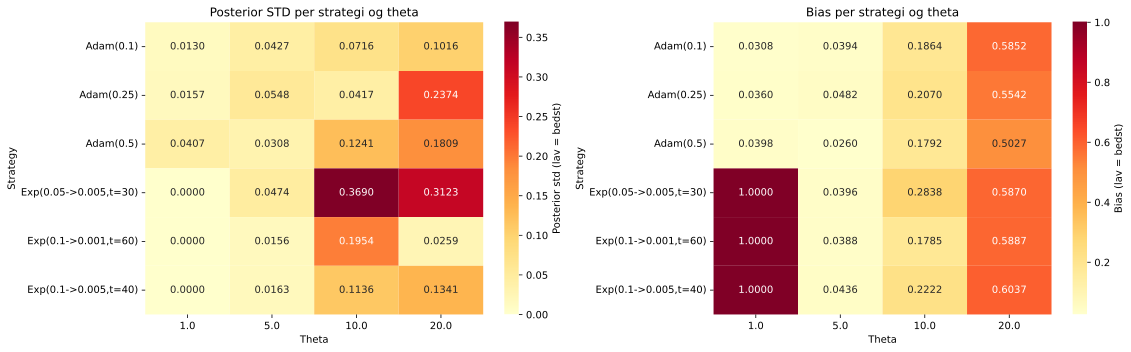


Global rangering (lav score = bedst til bavian-data):
Strategy
Adam(0.1)                0.162420
Adam(0.5)                0.187603
Adam(0.25)               0.193068
Exp(0.1->0.001,t=60)     0.284970
Exp(0.1->0.005,t=40)     0.299662
Exp(0.05->0.005,t=30)    0.420978


In [6]:
# Samlet heatmap: Bias og std over alle kombinationer
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_std  = df_bav.pivot_table(index='Strategy', columns='Theta', values='Std')
pivot_bias = df_bav.pivot_table(index='Strategy', columns='Theta', values='Bias')

sns.heatmap(pivot_std, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Posterior std (lav = bedst)'})
axes[0].set_title('Posterior STD per strategi og theta')

sns.heatmap(pivot_bias, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Bias (lav = bedst)'})
axes[1].set_title('Bias per strategi og theta')

plt.tight_layout(); plt.show()

# Find bedste globale strategi
df_bav['Score'] = df_bav['Std'] + 0.5*df_bav['Bias']
best_global = df_bav.groupby('Strategy')['Score'].mean().sort_values()
print("\nGlobal rangering (lav score = bedst til bavian-data):")
print(best_global.to_string())

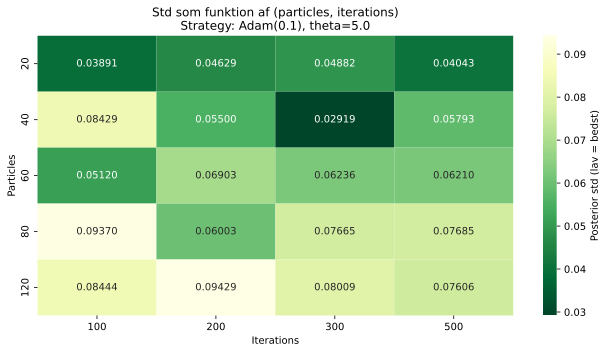


Bedste kombination: 40 particles, 300 iterations
  Std=0.02919  Bias=0.0681

Anbefaling til bavian NB07:
  optimizer = Adam(0.1)
  n_particles = 40
  n_iterations = 300


In [7]:
# Test: antal partikler vs. iterations 
best_lr_bav = best_global.index[0]
best_kwargs_bav = lr_configs_bav[best_lr_bav]
true_theta_bav = 5.0  # bavian baseline
graph_bav.update_weights([true_theta_bav])
data_bav_test = graph_bav.sample(3000)
prior_bav_test = DataPrior(graph_bav, data_bav_test)

rows_pt = []
for n_part in [20, 40, 60, 80, 120]:
    for n_iter in [100, 200, 300, 500]:
        sv_pt = graph_bav.svgd(data_bav_test, prior=prior_bav_test,
                                n_particles=n_part, n_iterations=n_iter,
                                **best_kwargs_bav)
        res_pt = sv_pt.get_results()
        rows_pt.append({
            'Particles': n_part, 'Iterations': n_iter,
            'Mean': round(res_pt['theta_mean'].item(), 4),
            'Std':  round(res_pt['theta_std'].item(), 5),
            'Bias': round(abs(res_pt['theta_mean'].item() - true_theta_bav), 4),
        })

df_pt = pd.DataFrame(rows_pt)
pivot_pt = df_pt.pivot_table(index='Particles', columns='Iterations', values='Std')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_pt, annot=True, fmt='.5f', cmap='YlGn_r', ax=ax,
            cbar_kws={'label': 'Posterior std (lav = bedst)'})
ax.set_title(f'Std som funktion af (particles, iterations)\nStrategy: {best_lr_bav}, theta={true_theta_bav}')
plt.tight_layout(); plt.show()

best_combo = df_pt.loc[df_pt['Std'].idxmin()]
print(f"\nBedste kombination: {int(best_combo['Particles'])} particles, {int(best_combo['Iterations'])} iterations")
print(f"  Std={best_combo['Std']:.5f}  Bias={best_combo['Bias']:.4f}")
print(f"\nAnbefaling til bavian NB07:")
print(f"  optimizer = {best_lr_bav}")
print(f"  n_particles = {int(best_combo['Particles'])}")
print(f"  n_iterations = {int(best_combo['Iterations'])}")